# Comparación 3-way: v5 vs v6 (post-pandemia) vs v6_all (post-pandemia + todos)

Hipótesis a contrastar:

1. **Filtrar pre-pandemia mejora la generalización**: si v6 ≥ v5 en split
   forward, los datos pre-2022 no aportan al régimen actual.
2. **El filtro `compras_historicas >= 3` sigue siendo necesario**: si v6_all
   cae > 1pp respecto a v6, vendedores con 1-2 meses de historia saturan
   el target (regla "1 compra → churn" domina).
3. **Volumen vs limpieza**: v6 pierde más de la mitad de la muestra de v5
   (9.841 vs 23.684). Es un trade-off entre tamaño y especificidad temporal.

Modelo: HGB balanceado.
Protocolos: GroupKFold + split temporal forward (últimos 6 meses test).


## 1. Setup


In [14]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, precision_recall_curve, roc_curve,
    confusion_matrix,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
np.random.seed(42)

PROJECT, DATASET = 'glamour-peru-dw', 'glamour_dw'
RANDOM_STATE = 42
N_SPLITS = 5
HORIZON_CHURN = 6   # meses

VARIANTS = ['v5', 'v6', 'v6_all']
THRESHOLD = 0.5   # umbral por defecto para métricas de matriz de confusión

bq = bigquery.Client(project=PROJECT)
dfs = {}
for v in VARIANTS:
    table = f'`{PROJECT}.{DATASET}.training_churn_{v}`'
    dfs[v] = bq.query(f'SELECT * FROM {table}').to_dataframe()
    df_ = dfs[v]
    print(f'{v:<8} → {len(df_):>6,} filas · {df_["id_vendedor"].nunique():>5,} vendedoras · '
          f'{df_["mes_obs"].nunique():>3} meses · churn {df_["churn"].mean():.4f} · '
          f'mes_obs [{df_["mes_obs"].min()} → {df_["mes_obs"].max()}]')


v5       → 23,684 filas · 4,211 vendedoras · 106 meses · churn 0.2750 · mes_obs [2017-01-01 → 2025-10-01]
v6       →  9,841 filas · 1,911 vendedoras ·  46 meses · churn 0.2587 · mes_obs [2022-01-01 → 2025-10-01]
v6_all   → 14,362 filas · 4,224 vendedoras ·  46 meses · churn 0.3658 · mes_obs [2022-01-01 → 2025-10-01]


## 2. Pipeline (idéntico a NB 05/07)


In [15]:
EXCLUDE = {
    'id_vendedor', 'mes_obs', 'mes_rank_obs',
    'fecha_ingreso',
    'id_coordinadora', 'ccodubigeo', 'distrito',
    'churn',
}
CATEGORICAL = ['sexo_vendedor', 'tipo_vendedor', 'departamento', 'provincia']

def prepare(df_: pd.DataFrame):
    feature_cols = [c for c in df_.columns if c not in EXCLUDE]
    numeric_cols = [c for c in feature_cols if c not in CATEGORICAL]
    df_ = df_.copy()
    for c in CATEGORICAL:
        df_[c] = df_[c].astype('string').fillna('NA')
    return df_, feature_cols, numeric_cols

def build_preprocessor(numeric_cols, scale=False):
    num_steps = [('impute', SimpleImputer(strategy='median'))]
    if scale: num_steps.append(('scale', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(num_steps), numeric_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='NA')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL),
    ])

def make_hgb(numeric_cols, **_):
    return Pipeline([('prep', build_preprocessor(numeric_cols, False)),
                     ('clf', HistGradientBoostingClassifier(class_weight='balanced',
                                                            max_iter=400, learning_rate=0.05,
                                                            random_state=RANDOM_STATE,
                                                            early_stopping=False))])

def make_logreg(numeric_cols, **_):
    return Pipeline([('prep', build_preprocessor(numeric_cols, True)),
                     ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                                random_state=RANDOM_STATE, n_jobs=-1))])

def make_lgbm(numeric_cols, **_):
    return Pipeline([('prep', build_preprocessor(numeric_cols, False)),
                     ('clf', LGBMClassifier(n_estimators=400, learning_rate=0.05,
                                            num_leaves=31, max_depth=-1,
                                            class_weight='balanced',
                                            random_state=RANDOM_STATE,
                                            n_jobs=-1, verbose=-1))])

def make_xgb(numeric_cols, scale_pos_weight=1.0, **_):
    return Pipeline([('prep', build_preprocessor(numeric_cols, False)),
                     ('clf', XGBClassifier(n_estimators=400, learning_rate=0.05,
                                           max_depth=6, tree_method='hist',
                                           scale_pos_weight=scale_pos_weight,
                                           random_state=RANDOM_STATE,
                                           eval_metric='logloss',
                                           n_jobs=-1, verbosity=0))])

def make_rf(numeric_cols, **_):
    return Pipeline([('prep', build_preprocessor(numeric_cols, False)),
                     ('clf', RandomForestClassifier(n_estimators=400,
                                                    max_depth=None,
                                                    min_samples_leaf=5,
                                                    class_weight='balanced',
                                                    random_state=RANDOM_STATE,
                                                    n_jobs=-1))])

def make_dummy(numeric_cols, **_):
    return Pipeline([('prep', build_preprocessor(numeric_cols, False)),
                     ('clf', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))])

# Lista de modelos entrenables (orden = orden de reporte)
MODELS = [
    ('LogReg', make_logreg),
    ('HGB',    make_hgb),
    ('LGBM',   make_lgbm),
    ('XGB',    make_xgb),
    ('RF',     make_rf),
]

def make_heuristic_scorer():
    def scorer(Xte):
        gap = Xte['meses_desde_compra_previa'].fillna(0).astype(float).values
        return 1.0 - np.exp(-gap / float(HORIZON_CHURN))
    return scorer

def confusion_metrics(y_true, proba, threshold=THRESHOLD):
    y_pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    n = tn + fp + fn + tp
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    acc  = (tp + tn) / n if n else 0.0
    return {
        'threshold': threshold,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'specificity': spec, 'f1': f1,
    }


## 3. GroupKFold sobre cada variante


In [16]:
cv = GroupKFold(n_splits=N_SPLITS)

def evaluate_gkf(df_, name):
    df_, feature_cols, numeric_cols = prepare(df_)
    X = df_[feature_cols].copy()
    y = df_['churn'].astype(int).values
    groups = df_['id_vendedor'].values

    out = {'variant': name, 'n': len(df_), 'n_vend': df_['id_vendedor'].nunique(),
           'churn_rate': float(y.mean()), 'models': {}}

    # heurística (no requiere fit)
    scorer = make_heuristic_scorer()
    proba_h = scorer(X)
    out['models']['Heurística'] = {
        'auc': roc_auc_score(y, proba_h),
        'ap':  average_precision_score(y, proba_h),
        'oof': proba_h,
        'y':   y,
        'cm':  confusion_metrics(y, proba_h, THRESHOLD),
    }

    spw_global = float((y == 0).sum()) / max(float((y == 1).sum()), 1.0)

    for model_name, factory in MODELS:
        oof = np.zeros(len(y), dtype=float)
        fold_aucs, fold_aps = [], []
        for tr, te in cv.split(X, y, groups):
            spw_fold = float((y[tr] == 0).sum()) / max(float((y[tr] == 1).sum()), 1.0)
            m = factory(numeric_cols, scale_pos_weight=spw_fold)
            m.fit(X.iloc[tr], y[tr])
            p = m.predict_proba(X.iloc[te])[:, 1]
            oof[te] = p
            fold_aucs.append(roc_auc_score(y[te], p))
            fold_aps.append(average_precision_score(y[te], p))
        out['models'][model_name] = {
            'auc_mean': float(np.mean(fold_aucs)),
            'auc_std':  float(np.std(fold_aucs)),
            'ap_mean':  float(np.mean(fold_aps)),
            'ap_std':   float(np.std(fold_aps)),
            'auc':      float(roc_auc_score(y, oof)),
            'ap':       float(average_precision_score(y, oof)),
            'oof':      oof,
            'y':        y,
            'cm':       confusion_metrics(y, oof, THRESHOLD),
        }
        cm = out['models'][model_name]['cm']
        print(f'{name:<8} {model_name:<8} AUC {out["models"][model_name]["auc"]:.4f}  '
              f'AP {out["models"][model_name]["ap"]:.4f}  '
              f'P {cm["precision"]:.3f}  R {cm["recall"]:.3f}  F1 {cm["f1"]:.3f}')
    return out

gkf_results = {}
for v in VARIANTS:
    print(f'\n→ {v}')
    gkf_results[v] = evaluate_gkf(dfs[v], v)

print('\nDone.')



→ v5
v5       LogReg   AUC 0.7452  AP 0.4968  P 0.422  R 0.737  F1 0.537
v5       HGB      AUC 0.7485  AP 0.5069  P 0.445  R 0.670  F1 0.535
v5       LGBM     AUC 0.7470  AP 0.5008  P 0.447  R 0.672  F1 0.537
v5       XGB      AUC 0.7484  AP 0.5047  P 0.442  R 0.686  F1 0.538
v5       RF       AUC 0.7465  AP 0.5003  P 0.480  R 0.557  F1 0.516

→ v6
v6       LogReg   AUC 0.7760  AP 0.5094  P 0.430  R 0.770  F1 0.552
v6       HGB      AUC 0.7645  AP 0.4982  P 0.462  R 0.621  F1 0.529
v6       LGBM     AUC 0.7644  AP 0.4954  P 0.457  R 0.608  F1 0.522
v6       XGB      AUC 0.7656  AP 0.4971  P 0.452  R 0.659  F1 0.536
v6       RF       AUC 0.7777  AP 0.5132  P 0.486  R 0.593  F1 0.534

→ v6_all
v6_all   LogReg   AUC 0.7958  AP 0.6641  P 0.570  R 0.780  F1 0.658
v6_all   HGB      AUC 0.7906  AP 0.6606  P 0.587  R 0.726  F1 0.649
v6_all   LGBM     AUC 0.7915  AP 0.6608  P 0.586  R 0.726  F1 0.649
v6_all   XGB      AUC 0.7900  AP 0.6536  P 0.584  R 0.745  F1 0.655
v6_all   RF       AUC 0.79

## 4. Comparación GroupKFold lado a lado


In [17]:
ALL_MODELS = ['Heurística'] + [n for n, _ in MODELS]

rows = []
for v in VARIANTS:
    r = gkf_results[v]
    for m in ALL_MODELS:
        d = r['models'][m]
        rows.append({
            'variant': v,
            'modelo':  m,
            'n_obs':   r['n'],
            'n_vend':  r['n_vend'],
            'churn_rate': r['churn_rate'],
            'AUC':     d['auc'],
            'PR-AUC':  d['ap'],
            'AUC mean ± std': f"{d.get('auc_mean', d['auc']):.4f} ± {d.get('auc_std', 0):.4f}",
        })
gkf_summary = pd.DataFrame(rows)
print(gkf_summary.to_string(index=False))
print()

# pivot: AUC por modelo × variante (lado a lado)
pivot_auc = gkf_summary.pivot(index='modelo', columns='variant', values='AUC').loc[ALL_MODELS]
pivot_ap  = gkf_summary.pivot(index='modelo', columns='variant', values='PR-AUC').loc[ALL_MODELS]
print('AUC por (modelo × variante):')
print(pivot_auc.round(4))
print()
print('PR-AUC por (modelo × variante):')
print(pivot_ap.round(4))

# Mejor modelo por variante
print()
print('Mejor modelo por variante (AUC):')
for v in VARIANTS:
    col = pivot_auc[v]
    print(f'  {v:<8} → {col.idxmax():<10} (AUC {col.max():.4f})')


variant     modelo  n_obs  n_vend  churn_rate      AUC   PR-AUC  AUC mean ± std
     v5 Heurística  23684    4211    0.275038 0.656780 0.414768 0.6568 ± 0.0000
     v5     LogReg  23684    4211    0.275038 0.745233 0.496822 0.7454 ± 0.0089
     v5        HGB  23684    4211    0.275038 0.748540 0.506946 0.7486 ± 0.0100
     v5       LGBM  23684    4211    0.275038 0.747009 0.500783 0.7472 ± 0.0100
     v5        XGB  23684    4211    0.275038 0.748413 0.504658 0.7487 ± 0.0097
     v5         RF  23684    4211    0.275038 0.746542 0.500282 0.7466 ± 0.0084
     v6 Heurística   9841    1911    0.258714 0.693945 0.439265 0.6939 ± 0.0000
     v6     LogReg   9841    1911    0.258714 0.776038 0.509449 0.7763 ± 0.0132
     v6        HGB   9841    1911    0.258714 0.764522 0.498188 0.7650 ± 0.0104
     v6       LGBM   9841    1911    0.258714 0.764431 0.495432 0.7651 ± 0.0091
     v6        XGB   9841    1911    0.258714 0.765569 0.497056 0.7661 ± 0.0092
     v6         RF   9841    1911    0.2

## 4.5. Matriz de confusión — GroupKFold (HGB, threshold = 0.5)

Métricas a partir de las predicciones OOF (out-of-fold) concatenadas. Cada
vendedora aporta predicciones generadas por un modelo que NO la vio en
entrenamiento (garantía de GroupKFold).


In [18]:
def cm_table(results, model_name='HGB'):
    rows = []
    for v in VARIANTS:
        cm = results[v]['models'][model_name]['cm']
        rows.append({
            'variant': v,
            'n':       cm['tn'] + cm['fp'] + cm['fn'] + cm['tp'],
            'TN':      cm['tn'],
            'FP':      cm['fp'],
            'FN':      cm['fn'],
            'TP':      cm['tp'],
            'accuracy':    cm['accuracy'],
            'precision':   cm['precision'],
            'recall':      cm['recall'],
            'specificity': cm['specificity'],
            'F1':          cm['f1'],
        })
    return pd.DataFrame(rows)

cm_gkf = cm_table(gkf_results, 'HGB')
print(f'Matriz de confusión @ threshold = {THRESHOLD}  (HGB, OOF GroupKFold)')
print(cm_gkf.round(4).to_string(index=False))

print()
print('También para LogReg y la heurística:')
for m in ['LogReg', 'Heurística']:
    print(f'\n--- {m} ---')
    print(cm_table(gkf_results, m).round(4).to_string(index=False))


Matriz de confusión @ threshold = 0.5  (HGB, OOF GroupKFold)
variant     n    TN   FP   FN   TP  accuracy  precision  recall  specificity     F1
     v5 23684 11717 5453 2148 4366    0.6791     0.4446  0.6702       0.6824 0.5346
     v6  9841  5452 1843  966 1580    0.7146     0.4616  0.6206       0.7474 0.5294
 v6_all 14362  6421 2687 1441 3813    0.7126     0.5866  0.7257       0.7050 0.6488

También para LogReg y la heurística:

--- LogReg ---
variant     n    TN   FP   FN   TP  accuracy  precision  recall  specificity     F1
     v5 23684 10604 6566 1714 4800    0.6504     0.4223  0.7369       0.6176 0.5369
     v6  9841  4700 2595  585 1961    0.6769     0.4304  0.7702       0.6443 0.5522
 v6_all 14362  6011 3097 1157 4097    0.7038     0.5695  0.7798       0.6600 0.6583

--- Heurística ---
variant     n    TN   FP   FN   TP  accuracy  precision  recall  specificity     F1
     v5 23684 14777 2393 4233 2281    0.7202     0.4880  0.3502       0.8606 0.4078
     v6  9841  6081 1214 

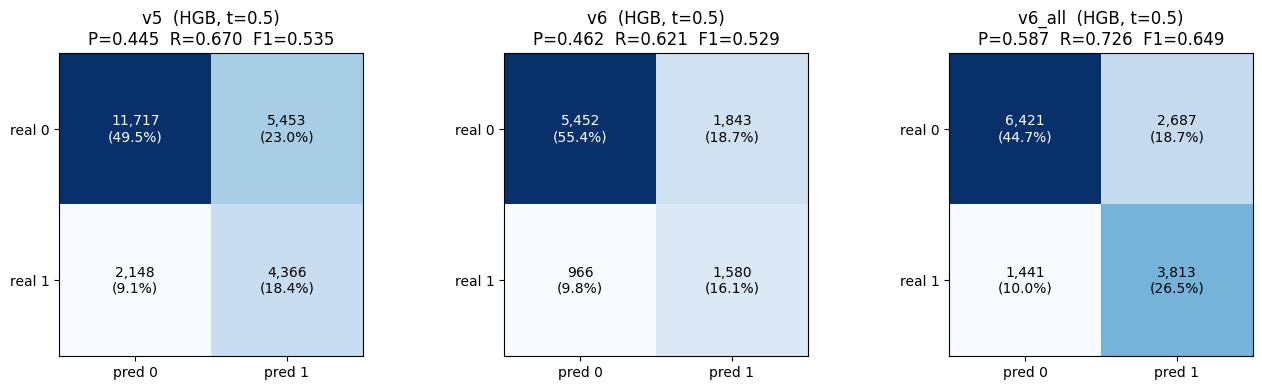

In [19]:
# Matriz de confusión visual (HGB, una por variante)
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.5 * len(VARIANTS), 4))
if len(VARIANTS) == 1:
    axes = [axes]
for ax, v in zip(axes, VARIANTS):
    cm = gkf_results[v]['models']['HGB']['cm']
    M = np.array([[cm['tn'], cm['fp']],
                  [cm['fn'], cm['tp']]])
    im = ax.imshow(M, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['pred 0', 'pred 1'])
    ax.set_yticklabels(['real 0', 'real 1'])
    ax.set_title(f'{v}  (HGB, t={THRESHOLD})\n'
                 f'P={cm["precision"]:.3f}  R={cm["recall"]:.3f}  F1={cm["f1"]:.3f}')
    total = M.sum()
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{M[i, j]:,}\n({M[i, j]/total:.1%})',
                    ha='center', va='center',
                    color='white' if M[i, j] > total * 0.3 else 'black')
plt.tight_layout()
plt.show()


## 5. Split temporal forward sobre cada variante


In [20]:
TEST_WINDOW = 6
GAP = HORIZON_CHURN + 1   # 7

def evaluate_forward(df_, name):
    df_, feature_cols, numeric_cols = prepare(df_)

    last_rank = int(df_['mes_rank_obs'].max())
    test_min  = last_rank - TEST_WINDOW + 1
    train_max = test_min - GAP

    df_tr = df_[df_['mes_rank_obs'] <= train_max]
    df_te = df_[df_['mes_rank_obs'].between(test_min, last_rank)]

    if df_tr.empty or df_te.empty:
        return None

    X_tr, y_tr = df_tr[feature_cols], df_tr['churn'].astype(int).values
    X_te, y_te = df_te[feature_cols], df_te['churn'].astype(int).values

    if y_te.sum() == 0 or y_te.sum() == len(y_te):
        return None

    spw = float((y_tr == 0).sum()) / max(float((y_tr == 1).sum()), 1.0)

    eval_t = df_te[['mes_rank_obs']].copy()
    eval_t['y'] = y_te

    models_out = {}
    for model_name, factory in MODELS:
        m = factory(numeric_cols, scale_pos_weight=spw)
        m.fit(X_tr, y_tr)
        proba = m.predict_proba(X_te)[:, 1]

        # AUC por mes test
        eval_t['p'] = proba
        per_mes = []
        for _, g in eval_t.groupby('mes_rank_obs'):
            yt, pp = g['y'].values, g['p'].values
            if 0 < yt.sum() < len(yt):
                per_mes.append(roc_auc_score(yt, pp))

        models_out[model_name] = {
            'auc_block': roc_auc_score(y_te, proba),
            'ap_block':  average_precision_score(y_te, proba),
            'auc_mean_per_mes': float(np.mean(per_mes)) if per_mes else float('nan'),
            'auc_std_per_mes':  float(np.std(per_mes))  if per_mes else float('nan'),
            'proba_test': proba,
            'cm': confusion_metrics(y_te, proba, THRESHOLD),
        }

    # Mantener compat: claves planas apuntan al modelo de referencia (HGB)
    ref = models_out['HGB']

    return {
        'variant': name,
        'n_train': len(df_tr), 'n_test': len(df_te),
        'churn_train': float(y_tr.mean()),
        'churn_test':  float(y_te.mean()),
        'overlap_pct': len(set(df_tr['id_vendedor']) & set(df_te['id_vendedor'])) /
                       max(df_te['id_vendedor'].nunique(), 1) * 100,
        'auc_block': ref['auc_block'], 'ap_block': ref['ap_block'],
        'auc_mean_per_mes': ref['auc_mean_per_mes'],
        'auc_std_per_mes':  ref['auc_std_per_mes'],
        'train_max_rank': train_max, 'test_min_rank': test_min, 'last_rank': last_rank,
        'y_test': y_te, 'proba_test': ref['proba_test'],
        'cm': ref['cm'],
        'models': models_out,
    }

fwd_results = {}
for v in VARIANTS:
    fwd_results[v] = evaluate_forward(dfs[v], v)
    r = fwd_results[v]
    if r is None:
        print(f'{v}: insuficiente data para split forward.')
        continue
    print(f"{v:<8} train [{r['n_train']:>5,} filas, churn {r['churn_train']:.3f}] "
          f"→ test [{r['n_test']:>5,} filas, churn {r['churn_test']:.3f}] "
          f"AUC bloque {r['auc_block']:.4f}  std/mes {r['auc_std_per_mes']:.4f}  "
          f"overlap {r['overlap_pct']:.1f}%  "
          f"P {r['cm']['precision']:.3f}  R {r['cm']['recall']:.3f}  F1 {r['cm']['f1']:.3f}")


v5       train [21,375 filas, churn 0.274] → test [1,061 filas, churn 0.255] AUC bloque 0.7509  std/mes 0.0308  overlap 74.1%  P 0.425  R 0.672  F1 0.521
v6       train [7,532 filas, churn 0.252] → test [1,061 filas, churn 0.255] AUC bloque 0.7424  std/mes 0.0368  overlap 71.8%  P 0.444  R 0.598  F1 0.509
v6_all   train [11,325 filas, churn 0.368] → test [1,276 filas, churn 0.320] AUC bloque 0.7614  std/mes 0.0292  overlap 67.4%  P 0.526  R 0.600  F1 0.561


## 6. Comparación split forward lado a lado


In [21]:
# Resumen por variante (ref = HGB para mantener compat con el resto del NB)
rows = []
for v in VARIANTS:
    r = fwd_results[v]
    if r is None:
        continue
    rows.append({
        'variant':       v,
        'n_train':       r['n_train'],
        'n_test':        r['n_test'],
        'churn_train':   r['churn_train'],
        'churn_test':    r['churn_test'],
        '|drift|':       abs(r['churn_train'] - r['churn_test']),
        'overlap_pct':   r['overlap_pct'],
        'AUC bloque':    r['auc_block'],
        'PR-AUC bloque': r['ap_block'],
        'AUC mean/mes':  r['auc_mean_per_mes'],
        'std AUC/mes':   r['auc_std_per_mes'],
    })
fwd_summary = pd.DataFrame(rows)
print('Forward (ref = HGB):')
print(fwd_summary.round(4).to_string(index=False))

# Comparación por modelo × variante en split forward
print()
print('AUC bloque por (modelo × variante) — split forward:')
fwd_rows = []
for v in VARIANTS:
    r = fwd_results[v]
    if r is None:
        continue
    for m_name, d in r['models'].items():
        fwd_rows.append({
            'variant': v, 'modelo': m_name,
            'AUC bloque':  d['auc_block'],
            'PR-AUC':      d['ap_block'],
            'AUC mean/mes': d['auc_mean_per_mes'],
            'std/mes':     d['auc_std_per_mes'],
        })
fwd_models_df = pd.DataFrame(fwd_rows)
pivot_fwd_auc = fwd_models_df.pivot(index='modelo', columns='variant', values='AUC bloque')
pivot_fwd_ap  = fwd_models_df.pivot(index='modelo', columns='variant', values='PR-AUC')
print(pivot_fwd_auc.round(4))
print()
print('PR-AUC por (modelo × variante) — split forward:')
print(pivot_fwd_ap.round(4))

print()
print('Mejor modelo por variante (forward, AUC):')
for v in pivot_fwd_auc.columns:
    col = pivot_fwd_auc[v]
    print(f'  {v:<8} → {col.idxmax():<10} (AUC {col.max():.4f})')


Forward (ref = HGB):
variant  n_train  n_test  churn_train  churn_test  |drift|  overlap_pct  AUC bloque  PR-AUC bloque  AUC mean/mes  std AUC/mes
     v5    21375    1061       0.2744      0.2554   0.0190      74.1007      0.7509         0.4824        0.7533       0.0308
     v6     7532    1061       0.2519      0.2554   0.0036      71.7626      0.7424         0.4585        0.7458       0.0368
 v6_all    11325    1276       0.3679      0.3197   0.0482      67.4003      0.7614         0.5804        0.7659       0.0292

AUC bloque por (modelo × variante) — split forward:
variant      v5      v6  v6_all
modelo                         
HGB      0.7509  0.7424  0.7614
LGBM     0.7548  0.7317  0.7585
LogReg   0.7552  0.7537  0.7822
RF       0.7560  0.7518  0.7735
XGB      0.7497  0.7376  0.7674

PR-AUC por (modelo × variante) — split forward:
variant      v5      v6  v6_all
modelo                         
HGB      0.4824  0.4585  0.5804
LGBM     0.4934  0.4509  0.5828
LogReg   0.4806  0.47

## 6.5. Matriz de confusión — split forward (HGB, threshold = 0.5)

Métricas sobre el bloque test (últimos 6 meses) tras entrenar sobre los meses
anteriores con GAP = 7 (= HORIZON_CHURN + 1) para evitar solapamiento del
target con las features de test.


In [22]:
def cm_table_forward(results, model_name='HGB'):
    rows = []
    for v in VARIANTS:
        r = results[v]
        if r is None:
            continue
        cm = r['models'][model_name]['cm']
        rows.append({
            'variant': v,
            'modelo':  model_name,
            'n_test':  cm['tn'] + cm['fp'] + cm['fn'] + cm['tp'],
            'TN':      cm['tn'],
            'FP':      cm['fp'],
            'FN':      cm['fn'],
            'TP':      cm['tp'],
            'accuracy':    cm['accuracy'],
            'precision':   cm['precision'],
            'recall':      cm['recall'],
            'specificity': cm['specificity'],
            'F1':          cm['f1'],
        })
    return pd.DataFrame(rows)

print(f'Matriz de confusión @ threshold = {THRESHOLD}  (split forward)')
for m_name, _ in MODELS:
    print(f'\n--- {m_name} ---')
    print(cm_table_forward(fwd_results, m_name).round(4).to_string(index=False))


Matriz de confusión @ threshold = 0.5  (split forward)

--- LogReg ---
variant modelo  n_test  TN  FP  FN  TP  accuracy  precision  recall  specificity     F1
     v5 LogReg    1061 504 286  68 203    0.6664     0.4151  0.7491       0.6380 0.5342
     v6 LogReg    1061 472 318  61 210    0.6428     0.3977  0.7749       0.5975 0.5257
 v6_all LogReg    1276 614 254 127 281    0.7014     0.5252  0.6887       0.7074 0.5960

--- HGB ---
variant modelo  n_test  TN  FP  FN  TP  accuracy  precision  recall  specificity     F1
     v5    HGB    1061 544 246  89 182    0.6843     0.4252  0.6716       0.6886 0.5207
     v6    HGB    1061 587 203 109 162    0.7059     0.4438  0.5978       0.7430 0.5094
 v6_all    HGB    1276 647 221 163 245    0.6991     0.5258  0.6005       0.7454 0.5606

--- LGBM ---
variant modelo  n_test  TN  FP  FN  TP  accuracy  precision  recall  specificity     F1
     v5   LGBM    1061 557 233 100 171    0.6861     0.4233  0.6310       0.7051 0.5067
     v6   LGBM    1061

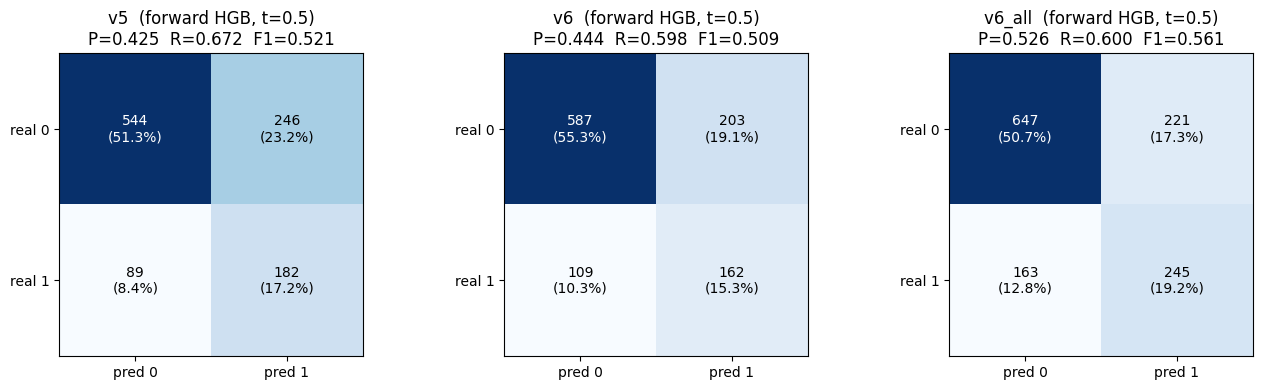

In [23]:
# Matriz de confusión visual (split forward, HGB, una por variante)
present = [v for v in VARIANTS if fwd_results[v] is not None]
fig, axes = plt.subplots(1, len(present), figsize=(4.5 * len(present), 4))
if len(present) == 1:
    axes = [axes]
for ax, v in zip(axes, present):
    cm = fwd_results[v]['cm']
    M = np.array([[cm['tn'], cm['fp']],
                  [cm['fn'], cm['tp']]])
    im = ax.imshow(M, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['pred 0', 'pred 1'])
    ax.set_yticklabels(['real 0', 'real 1'])
    ax.set_title(f'{v}  (forward HGB, t={THRESHOLD})\n'
                 f'P={cm["precision"]:.3f}  R={cm["recall"]:.3f}  F1={cm["f1"]:.3f}')
    total = M.sum()
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{M[i, j]:,}\n({M[i, j]/total:.1%})',
                    ha='center', va='center',
                    color='white' if M[i, j] > total * 0.3 else 'black')
plt.tight_layout()
plt.show()


## 6.6. Sensibilidad al threshold (HGB, ambos protocolos)

Recorre thresholds y muestra cómo cambia precision / recall / F1. Útil para
elegir un punto operacional según el costo de FP vs FN del negocio.


GroupKFold OOF — F1 máximo por (modelo × variante):

--- LogReg ---
  v5       F1 máx = 0.539 en t = 0.45  (P 0.405  R 0.804)
  v6       F1 máx = 0.552 en t = 0.50  (P 0.430  R 0.770)
  v6_all   F1 máx = 0.661 en t = 0.45  (P 0.550  R 0.828)

--- HGB ---
  v5       F1 máx = 0.542 en t = 0.45  (P 0.426  R 0.742)
  v6       F1 máx = 0.544 en t = 0.35  (P 0.418  R 0.777)
  v6_all   F1 máx = 0.656 en t = 0.40  (P 0.548  R 0.817)

--- LGBM ---
  v5       F1 máx = 0.542 en t = 0.45  (P 0.427  R 0.743)
  v6       F1 máx = 0.545 en t = 0.35  (P 0.420  R 0.777)
  v6_all   F1 máx = 0.657 en t = 0.40  (P 0.549  R 0.820)

--- XGB ---
  v5       F1 máx = 0.543 en t = 0.40  (P 0.407  R 0.814)
  v6       F1 máx = 0.547 en t = 0.40  (P 0.423  R 0.771)
  v6_all   F1 máx = 0.656 en t = 0.40  (P 0.540  R 0.836)

--- RF ---
  v5       F1 máx = 0.541 en t = 0.40  (P 0.424  R 0.746)
  v6       F1 máx = 0.553 en t = 0.35  (P 0.417  R 0.821)
  v6_all   F1 máx = 0.660 en t = 0.40  (P 0.554  R 0.818)

Split for

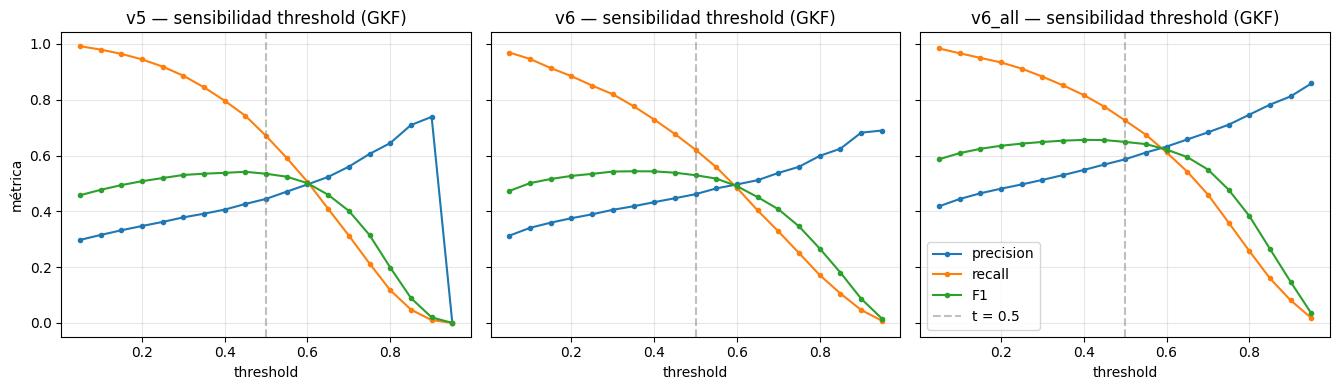

In [24]:
def threshold_sweep(y, proba, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 17)
    rows = []
    for t in thresholds:
        cm = confusion_metrics(y, proba, t)
        rows.append({
            'threshold': round(float(t), 3),
            'precision': cm['precision'],
            'recall':    cm['recall'],
            'F1':        cm['f1'],
            'TP':        cm['tp'], 'FP': cm['fp'],
            'FN':        cm['fn'], 'TN': cm['tn'],
        })
    return pd.DataFrame(rows)

# Threshold óptimo F1 por (modelo × variante) — GroupKFold OOF
print('GroupKFold OOF — F1 máximo por (modelo × variante):')
for m_name, _ in MODELS:
    print(f'\n--- {m_name} ---')
    for v in VARIANTS:
        g = gkf_results[v]['models'][m_name]
        sweep = threshold_sweep(g['y'], g['oof'])
        best = sweep.loc[sweep['F1'].idxmax()]
        print(f"  {v:<8} F1 máx = {best['F1']:.3f} en t = {best['threshold']:.2f}  "
              f"(P {best['precision']:.3f}  R {best['recall']:.3f})")

print()
print('Split forward — F1 máximo por (modelo × variante):')
for m_name, _ in MODELS:
    print(f'\n--- {m_name} ---')
    for v in VARIANTS:
        r = fwd_results[v]
        if r is None:
            continue
        d = r['models'][m_name]
        sweep = threshold_sweep(r['y_test'], d['proba_test'])
        best = sweep.loc[sweep['F1'].idxmax()]
        print(f"  {v:<8} F1 máx = {best['F1']:.3f} en t = {best['threshold']:.2f}  "
              f"(P {best['precision']:.3f}  R {best['recall']:.3f})")

# Curvas P/R/F1 por variante (GroupKFold)
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.5 * len(VARIANTS), 4), sharey=True)
if len(VARIANTS) == 1:
    axes = [axes]
for ax, v in zip(axes, VARIANTS):
    g = gkf_results[v]['models']['HGB']
    sweep = threshold_sweep(g['y'], g['oof'], np.linspace(0.05, 0.95, 19))
    ax.plot(sweep['threshold'], sweep['precision'], label='precision', marker='o', ms=3)
    ax.plot(sweep['threshold'], sweep['recall'],    label='recall',    marker='o', ms=3)
    ax.plot(sweep['threshold'], sweep['F1'],        label='F1',        marker='o', ms=3)
    ax.axvline(THRESHOLD, color='gray', ls='--', alpha=0.5, label=f't = {THRESHOLD}')
    ax.set_title(f'{v} — sensibilidad threshold (GKF)')
    ax.set_xlabel('threshold')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('métrica')
axes[-1].legend(loc='best')
plt.tight_layout()
plt.show()


## 7. Veredicto


In [25]:
def fmt(r, key, fmt_str='.4f'):
    return ('—' if r is None else format(r[key], fmt_str))

print('=' * 90)
print('VEREDICTO 3-WAY: v5 vs v6 (post-pandemia) vs v6_all (post-pandemia + todos)')
print('=' * 90)
print()
print(f"{'Métrica':<35} {'v5':>15} {'v6':>15} {'v6_all':>15}")
print('-' * 90)

# AUC GroupKFold (HGB)
v5_a = gkf_results['v5']['models']['HGB']['auc']
v6_a = gkf_results['v6']['models']['HGB']['auc']
v6a_a = gkf_results['v6_all']['models']['HGB']['auc']
print(f"{'AUC GroupKFold (HGB)':<35} {v5_a:>15.4f} {v6_a:>15.4f} {v6a_a:>15.4f}")

# PR-AUC GroupKFold (HGB)
v5_p = gkf_results['v5']['models']['HGB']['ap']
v6_p = gkf_results['v6']['models']['HGB']['ap']
v6a_p = gkf_results['v6_all']['models']['HGB']['ap']
print(f"{'PR-AUC GroupKFold (HGB)':<35} {v5_p:>15.4f} {v6_p:>15.4f} {v6a_p:>15.4f}")

# churn rate
print(f"{'Churn rate (global)':<35} "
      f"{gkf_results['v5']['churn_rate']:>15.4f} "
      f"{gkf_results['v6']['churn_rate']:>15.4f} "
      f"{gkf_results['v6_all']['churn_rate']:>15.4f}")

# n filas / vendedoras
print(f"{'n filas':<35} "
      f"{gkf_results['v5']['n']:>15,} "
      f"{gkf_results['v6']['n']:>15,} "
      f"{gkf_results['v6_all']['n']:>15,}")
print(f"{'n vendedoras':<35} "
      f"{gkf_results['v5']['n_vend']:>15,} "
      f"{gkf_results['v6']['n_vend']:>15,} "
      f"{gkf_results['v6_all']['n_vend']:>15,}")

# split forward
print()
print(f"{'AUC split forward':<35} "
      f"{fmt(fwd_results['v5'], 'auc_block')!s:>15} "
      f"{fmt(fwd_results['v6'], 'auc_block')!s:>15} "
      f"{fmt(fwd_results['v6_all'], 'auc_block')!s:>15}")
print(f"{'Std AUC por mes (test)':<35} "
      f"{fmt(fwd_results['v5'], 'auc_std_per_mes')!s:>15} "
      f"{fmt(fwd_results['v6'], 'auc_std_per_mes')!s:>15} "
      f"{fmt(fwd_results['v6_all'], 'auc_std_per_mes')!s:>15}")
print(f"{'|Δ churn rate train↔test|':<35} "
      f"{fmt(fwd_results['v5'], '|drift|') if False else format(abs(fwd_results['v5']['churn_train']-fwd_results['v5']['churn_test']), '.4f'):>15} "
      f"{format(abs(fwd_results['v6']['churn_train']-fwd_results['v6']['churn_test']), '.4f'):>15} "
      f"{format(abs(fwd_results['v6_all']['churn_train']-fwd_results['v6_all']['churn_test']), '.4f'):>15}")
print()
print('Decisión queda escrita en la celda markdown siguiente.')


VEREDICTO 3-WAY: v5 vs v6 (post-pandemia) vs v6_all (post-pandemia + todos)

Métrica                                          v5              v6          v6_all
------------------------------------------------------------------------------------------
AUC GroupKFold (HGB)                         0.7485          0.7645          0.7906
PR-AUC GroupKFold (HGB)                      0.5069          0.4982          0.6606
Churn rate (global)                          0.2750          0.2587          0.3658
n filas                                      23,684           9,841          14,362
n vendedoras                                  4,211           1,911           4,224

AUC split forward                            0.7509          0.7424          0.7614
Std AUC por mes (test)                       0.0308          0.0368          0.0292
|Δ churn rate train↔test|                    0.0190          0.0036          0.0482

Decisión queda escrita en la celda markdown siguiente.


### Decisión

*Esta celda se completa después de inspeccionar los outputs.*

Llenar:

| Hipótesis | Predicción | Resultado | Veredicto |
|---|---|---|---|
| Filtrar pre-pandemia mejora generalización | v6 ≥ v5 en split forward | … | ☐ |
| Filtro hist≥3 sigue necesario post-pandemia | v6 > v6_all en AUC | … | ☐ |
| Volumen de v5 compensa el ruido pre-pandemia | v5 ≥ v6 en GroupKFold | … | ☐ |

**Decisión final**: …

Opciones según resultado:
- **v6 gana** (AUC sube en forward) → migrar a v6 productivo.
- **v6_all gana** (AUC sube quitando filtro) → considerar relajar el filtro
  de población; documentar que en el régimen post-pandemia los vendedores
  con poca historia no saturan el target.
- **v5 gana** (volumen importa más que limpieza temporal) → mantener v5.
- **Empate técnico (Δ < 0.5pp)** → quedarse con v5 (más datos, menos
  riesgo de overfitting a régimen actual; más fácil mantener).
